# 2. Multi-Objective Optimization — MOMILP + AUGMECON2

Bước 2 của chuỗi **Demand → Multi-Objective Optimization → TOPSIS**.

- **Đọc:** `Model - Data used/` (kho, chi phí, DOS, lead time) và `Model Outputs/demand.parquet` (từ notebook 1).
- **Mô hình:** MILP tất định chọn mở/đóng kho (`Y_j`) và luồng hàng; cầu = `d_k` (pallet/năm, cột `DemandPallet`, Decision_Log 2.4, 6.1).
- **Mục tiêu:** `f1` tổng chi phí (min), `f2` cầu giao ngoài chuẩn lead time `L_max` (min), `f3` CO2 (min).
- **Giải:** Pyomo + HiGHS (`appsi_highs`), AUGMECON2 → tập Pareto.
- **Ghi:** `Model Outputs/pareto.parquet` → notebook 3 đọc.

**Thứ tự xây (Decision_Log 1.6):** `f1` một mình → kiểm tra → độ nhạy cầu → thêm `f2`, `f3` → payoff table → AUGMECON2.

## 2.0 Setup

*(code: import thư viện, đọc dữ liệu)*

In [49]:
# ===== 2.0 SETUP =====
import pandas as pd                       # xử lý bảng
import numpy as np                        # tính toán
from pathlib import Path                  # ghép đường dẫn

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

IN = Path("../Model - Data used")         # data đã clean (2 notebook Validation)
OUT = Path("../Model Outputs")            # kết quả các notebook model

# Bảng tuyến kho -> khách: "day_du" = mọi kho × mọi nhóm (Decision_Log 4.3a), "cong_ty" = chỉ tuyến của công ty (để so sánh)
TUYEN = "day_du"
FILE_LM = "cost_lastmile_b2b_full.parquet" if TUYEN == "day_du" else "cost_lastmile_b2b.parquet"
FILE_TR = "cost_transfer_full.parquet" if TUYEN == "day_du" else "cost_transfer.parquet"      # tuyến kho -> kho (Decision_Log 4.3b)

DAYS_YEAR = 360                           # số ngày / năm khi đổi sức chứa ra thông lượng (giống công ty, Decision_Log 4.4)

# --- Đọc dữ liệu ---
fac = pd.read_parquet(IN / "facility_master.parquet")         # 53 kho: loại kho, sức chứa, tiền thuê, phí handling
dos = pd.read_parquet(IN / "dos.parquet")                     # số ngày hàng nằm kho (DOS) mỗi kho
tr = pd.read_parquet(IN / FILE_TR)                   # tuyến kho -> kho, IDR/pallet (giá 2025)
lm = pd.read_parquet(IN / FILE_LM)                            # tuyến kho -> nhóm khách, IDR/pallet (giá 2025)
lead = pd.read_parquet(IN / "lead_time.parquet")              # thời gian giao + khoảng cách mỗi tuyến
dem = pd.read_parquet(OUT / "demand.parquet")                 # cầu mỗi nhóm khách, pallet/năm (Demand.ipynb)

for ten, bang in [("kho", fac), ("DOS", dos), ("transfer", tr), ("last-mile", lm), ("lead time", lead), ("cầu", dem)]:
    print(f"{ten:10s}: {len(bang):>6,} dòng")

kho       :     53 dòng
DOS       :     53 dòng
transfer  :  1,148 dòng
last-mile : 147,387 dòng
lead time : 15,139 dòng
cầu       :  3,346 dòng


## 2.1 Problem description

### 2.1.1 Network structure and assumptions

**Mạng lưới phân phối:**

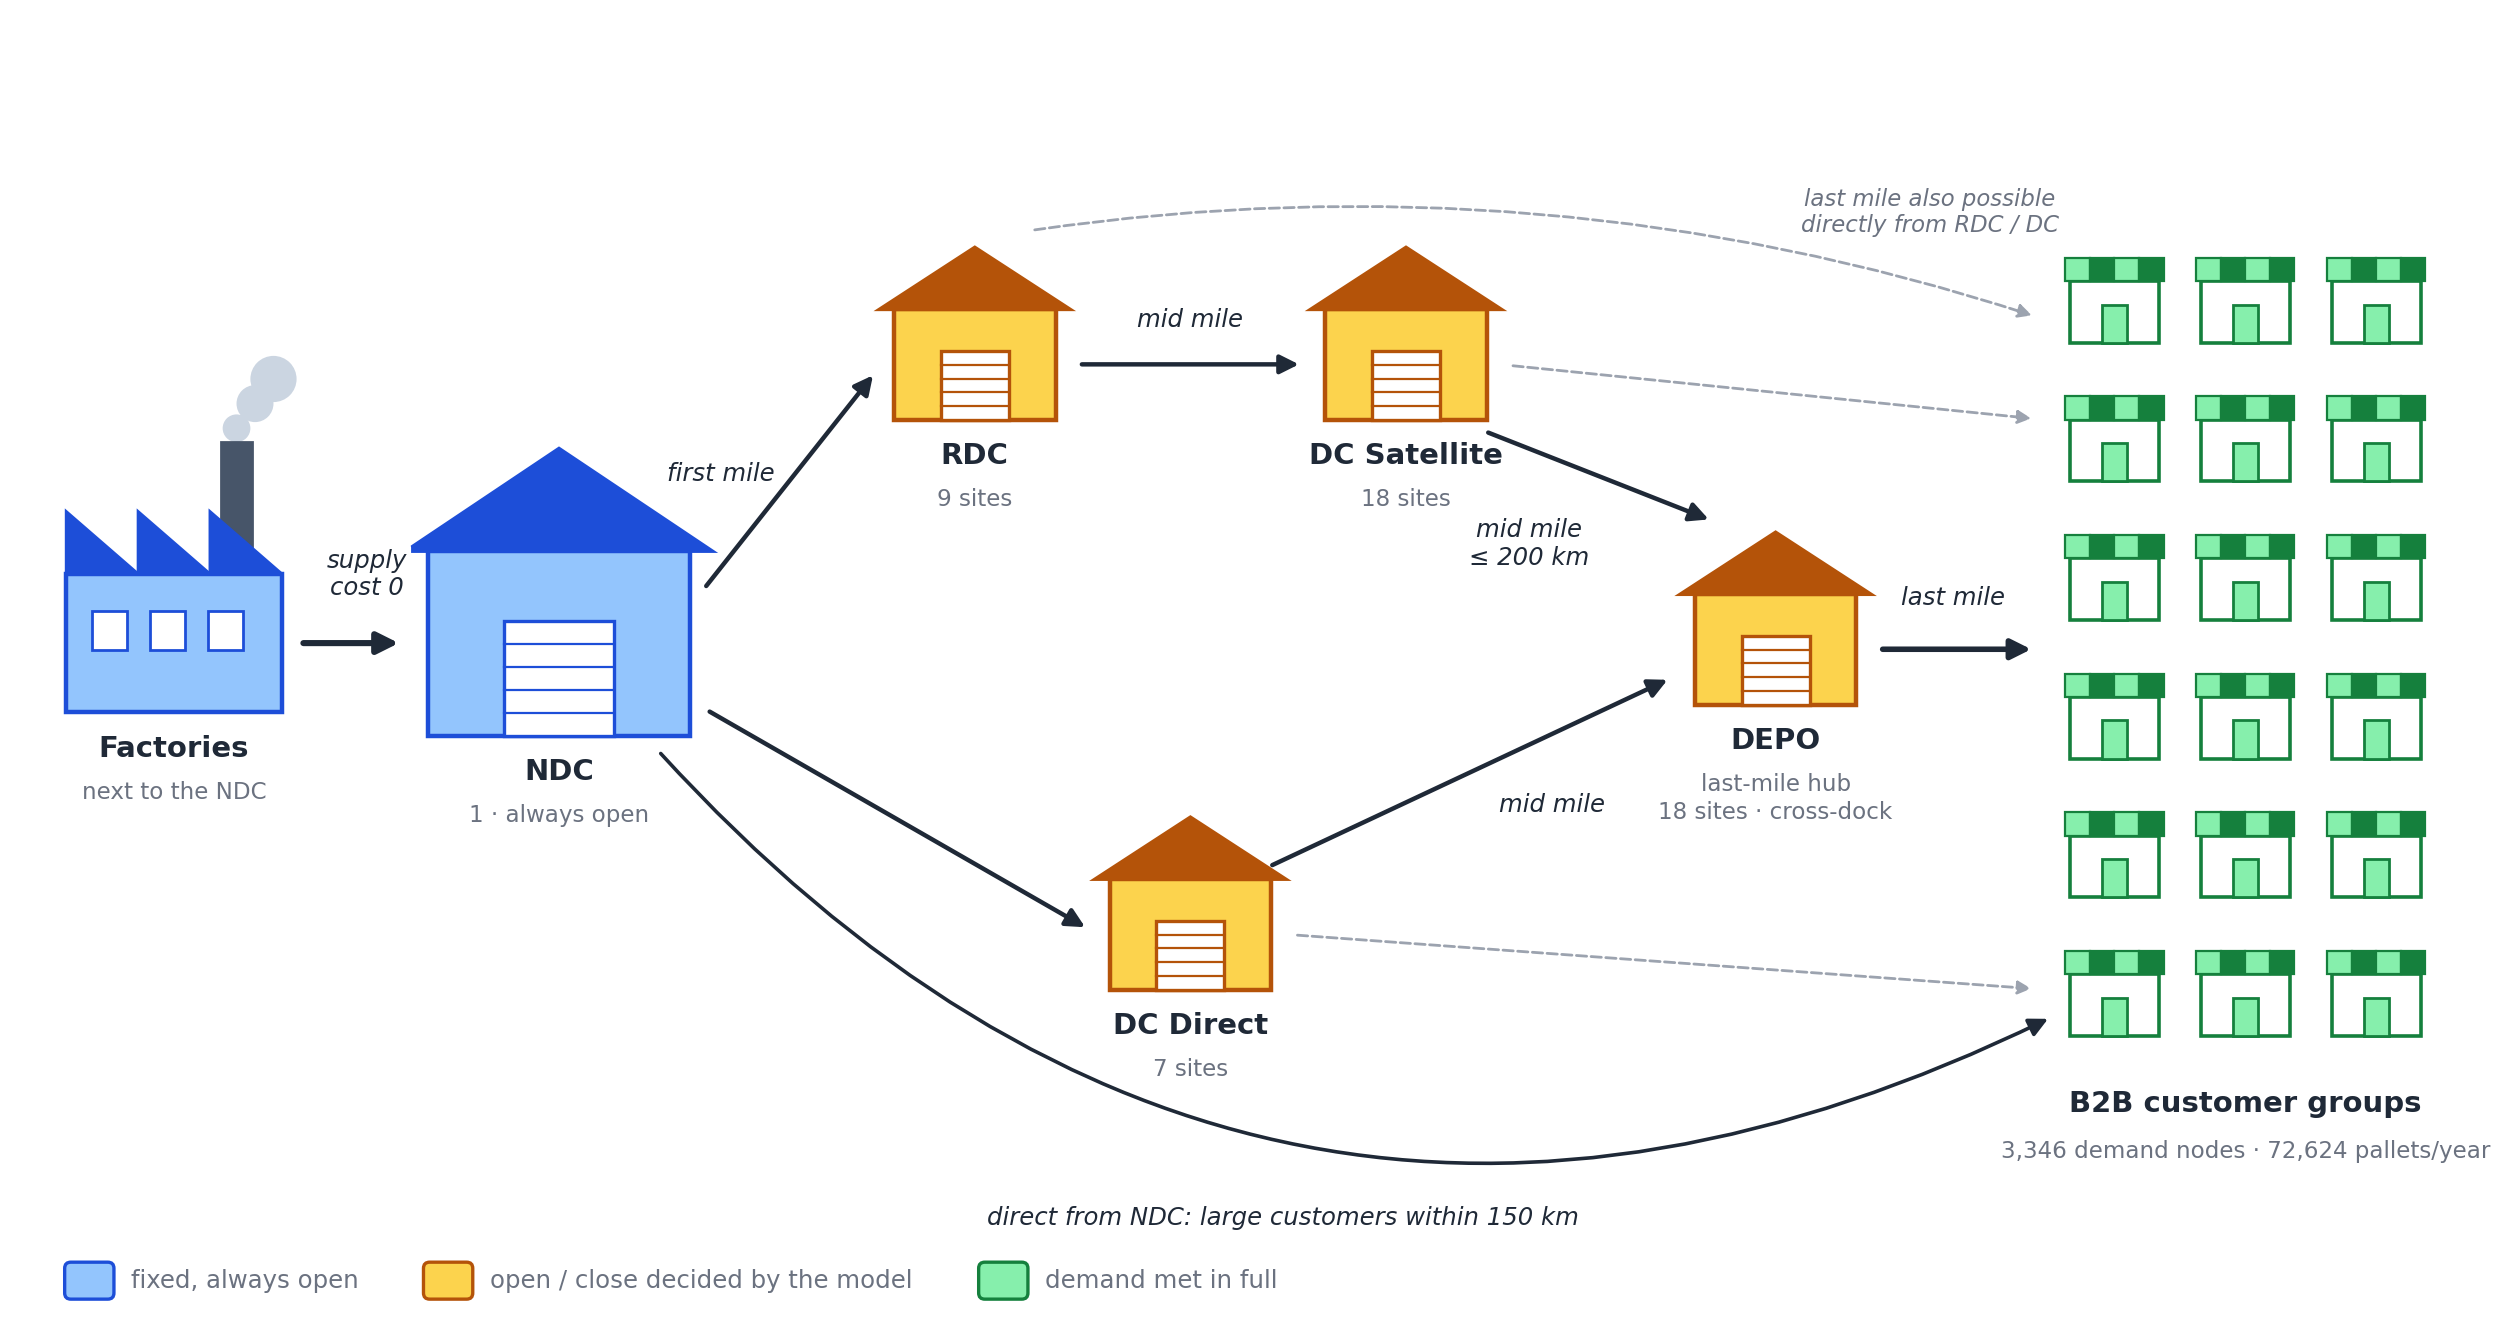

*Hình cũng được lưu ở `Model Outputs/figures/network_structure.png` để đưa vào luận văn.*

Luồng hàng theo sơ đồ mạng của công ty:

- **Nhà máy → NDC** (phí 0). **NDC** luôn mở.
- **First mile:** NDC → RDC hoặc NDC → DC Direct.
- **Mid mile:** RDC → DC Satellite → DEPO (last-mile hub, ≤ 200 km), hoặc DC Direct → DEPO.
- **Last mile:** DEPO → khách. RDC và DC cũng giao thẳng được cho khách nếu bảng giá có tuyến đó.
- **NDC giao thẳng** chỉ cho khách lớn trong bán kính 150 km.

Mô hình **không ép cứng** thứ tự này: hàng được đi theo **mọi tuyến có trong bảng giá** của công ty. Bảng giá đã được công ty lọc theo đúng các luật trên, nên luồng tối ưu tự nằm trong khuôn khổ đó (Decision_Log 4.3). Công ty cũng làm như vậy và chỉ đặt tên loại kho **sau khi** chạy mô hình, dựa vào luồng thực tế. 52 kho ngoài NDC được mô hình **tự chọn mở hay đóng**.

**Giả định:**

| # | Giả định | Decision_Log |
|---|---|---|
| 1 | **Một kỳ = một năm** (dữ liệu 2025). Cầu, chi phí, sức chứa đều tính theo năm | 2.4 |
| 2 | **Một sản phẩm gộp**, đo bằng **pallet**. Mỗi sản phẩm được đổi cái → pallet trước khi cộng | 2.3 |
| 3 | Chỉ kênh **B2B**, chỉ **Indonesia** | 2.1, 2.2 |
| 4 | **Cầu tất định**: mỗi nhóm khách một con số pallet/năm. Rủi ro cầu được xét bằng phân tích độ nhạy +10%, +20% | 1.3, 6.1 |
| 5 | Nhà máy nằm cạnh NDC: chặng nhà máy → NDC **phí 0, không giới hạn** hàng | 4.1 |
| 6 | Chỉ xét **kho đang có**, không xây kho mới | 4.2, 4.2a |
| 7 | Chỉ dùng **tuyến có trong bảng giá** của công ty (369 tuyến kho → kho, khoảng 14,770 tuyến kho → khách) | 4.3 |
| 8 | **Phải giao đủ 100% cầu**, không cho thiếu hàng | — |
| 9 | Một nhóm khách **có thể nhận hàng từ nhiều kho** (không bắt buộc 1 kho duy nhất) | — |
| 10 | **DEPO** là kho trung chuyển (cross-dock, DOS = 0): không giới hạn sức chứa | 4.5 |
| 11 | Mọi chi phí ở **mặt bằng giá 2025** (giá 2030 của công ty đã được quy về 2025) | 5.7 |

### 2.1.2 Sets and indices

| Tập | Chỉ số | Gồm những gì | Số phần tử |
|---|---|---|---|
| $J$ | $i, j, l$ | Tất cả kho | 53 |
| $J^{dec} \subset J$ | $j$ | Kho mô hình chọn mở/đóng (mọi kho trừ NDC) | 52 |
| $K$ | $k$ | Nhóm khách B2B (nút cầu) | 3,346 |
| $A^{tr} \subset J \times J$ | $(i, j)$ | Tuyến kho → kho có trong bảng giá | 369 |
| $A^{lm} \subset J \times K$ | $(j, k)$ | Tuyến kho → nhóm khách có trong bảng giá | ≈ 14,770 |

Ký hiệu ngắn: $J^{ra}_j$ = các kho mà kho $j$ chở sang được; $J^{vao}_j$ = các kho chở được vào kho $j$; $K_j$ = các nhóm khách kho $j$ giao được; $J_k$ = các kho giao được cho nhóm $k$.

### 2.1.3 Parameters

| Ký hiệu | Ý nghĩa | Đơn vị | Nguồn (cột) | Decision_Log |
|---|---|---|---|---|
| $d_k$ | Cầu của nhóm khách $k$ | pallet/năm | `demand.parquet` (`DemandPallet`) | 5.1, 5.9 |
| $F_j$ | Tiền thuê kho $j$ cả năm | IDR/năm | `facility_master` (`FixedStorageCost`) | 4.4b |
| $h_j$ | Phí handling 1 pallet xuất khỏi kho $j$ | IDR/pallet | `facility_master` (`B2BHandlingCostPerPallet`) | 3.1 |
| $c^{tr}_{ij}$ | Phí chở 1 pallet từ kho $i$ sang kho $j$ | IDR/pallet | `cost_transfer` (`CostPerPallet`) | 4.3, 5.7 |
| $c^{lm}_{jk}$ | Phí chở 1 pallet từ kho $j$ tới nhóm $k$ | IDR/pallet | `cost_lastmile_b2b` (`CostPerPallet`) | 5.7 |
| $DOS_j$ | Số ngày hàng nằm trong kho $j$ | ngày | `dos` (`DOS`) | 4.5 |
| $Cap_j$ | Sức chứa thông lượng = `CapacityInPallet` × 360 / $DOS_j$ (DEPO: không giới hạn) | pallet/năm | `facility_master` + `dos` | 4.4 |

Dùng cho `f2`, `f3` (thêm sau):

| Ký hiệu | Ý nghĩa | Đơn vị | Nguồn |
|---|---|---|---|
| $LT_{jk}$ | Thời gian giao từ kho $j$ tới nhóm $k$ | ngày | `lead_time` (`TotalLeadTimeInDays`) |
| $L^{max}$ | Ngưỡng giao "kịp" | ngày | chưa chốt (Decision_Log 3.4) |
| $km_{ij}$, $km_{jk}$ | Khoảng cách đường bộ / đường biển | km | `lead_time` |
| $w_k$ | Tấn trên 1 pallet của nhóm $k$ | tấn/pallet | `demand.parquet` (`TonPerPallet`) |

### 2.1.4 Decision variables

| Biến | Loại | Ý nghĩa | Đơn vị |
|---|---|---|---|
| $Y_j$, $j \in J^{dec}$ | nhị phân (0/1) | 1 = mở kho $j$, 0 = đóng. NDC cố định $Y_{NDC} = 1$ | — |
| $T_{ij}$, $(i,j) \in A^{tr}$ | liên tục, ≥ 0 | Số pallet chở từ kho $i$ sang kho $j$ | pallet/năm |
| $X_{jk}$, $(j,k) \in A^{lm}$ | liên tục, ≥ 0 | Số pallet kho $j$ giao cho nhóm khách $k$ | pallet/năm |

Biến phụ (tính từ biến chính, không phải quyết định riêng): lượng xuất khỏi kho $j$, $\;Out_j = \sum_{l \in J^{ra}_j} T_{jl} + \sum_{k \in K_j} X_{jk}$, dùng cho phí handling và sức chứa.

Mô hình có 52 biến nhị phân và khoảng 15 nghìn biến liên tục.

## 2.2 Data preparation and feasibility check

### 2.2.1 Parameter construction

*(code: tạo bảng tham số cho mô hình)*

In [50]:
# ===== 2.2.1 TẠO THAM SỐ CHO MÔ HÌNH =====
# Đọc lại bảng kho và tuyến last-mile mỗi lần chạy ô này -> chạy lại bao nhiêu lần cũng không lỗi
fac = pd.read_parquet(IN / "facility_master.parquet").drop(columns=["DOS"], errors="ignore")
lm = pd.read_parquet(IN / FILE_LM)

# --- Tập kho J: NDC luôn mở (FIXED), các kho còn lại mô hình tự chọn mở/đóng (DECISION) ---
fac = fac.merge(dos[["LocationID", "DOS"]], on="LocationID", how="left", validate="one_to_one")
assert fac["DOS"].notna().all(), "Có kho thiếu DOS"
J = sorted(fac["LocationID"])                                            # 53 kho
J_dec = sorted(fac.loc[fac["Role"] == "DECISION", "LocationID"])         # 52 kho để mô hình chọn
NDC = fac.loc[fac["Role"] == "FIXED", "LocationID"].item()               # mã NDC (luôn mở)

# --- Tập nhóm khách K: lấy theo file cầu (3.346 nhóm, đã bỏ khách kênh Manufacturer) ---
K = sorted(dem["ShipToGroupID"])
d = dem.set_index("ShipToGroupID")["DemandPallet"]                       # d_k: pallet/năm

# --- Tuyến last-mile: chỉ giữ tuyến tới nhóm có trong K ---
lm_truoc = len(lm)
lm = lm[lm["DestinationID"].isin(K)].copy()
print(f"Tuyến last-mile: {lm_truoc:,} -> {len(lm):,} (bỏ tuyến tới nhóm không còn trong cầu)")
assert set(lm["DestinationID"]) == set(K), "Có nhóm khách không có kho nào giao tới"
assert set(lm["OriginID"]) <= set(J) and set(tr["OriginID"]) <= set(J) and set(tr["DestinationID"]) <= set(J)

# --- Tham số mỗi kho ---
fac = fac.set_index("LocationID")
f_fixed = fac["FixedStorageCost"]                                        # tiền thuê kho, IDR/năm (Decision_Log 4.4b)
h = fac["B2BHandlingCostPerPallet"]                                      # phí handling, IDR/pallet hàng xuất ra
# Sức chứa thông lượng (pallet/năm) = chỗ chứa × 360 / DOS. DEPO: DOS = 0 (cross-dock) -> không giới hạn
cap = pd.Series(np.where(fac["DOS"] > 0, fac["CapacityInPallet"] * DAYS_YEAR / fac["DOS"].where(fac["DOS"] > 0), np.inf),
                index=fac.index, name="CapYear")

print(f"Kho: {len(J)} (NDC = {NDC}, quyết định: {len(J_dec)}) | nhóm khách: {len(K):,} | "
      f"tuyến transfer: {len(tr):,} | tuyến last-mile: {len(lm):,}")
print(f"Tổng cầu: {d.sum():,.0f} pallet/năm | tổng tiền thuê nếu mở hết: {f_fixed.sum() / 1e9:,.1f} tỷ IDR/năm")

Tuyến last-mile: 147,387 -> 147,336 (bỏ tuyến tới nhóm không còn trong cầu)
Kho: 53 (NDC = NDC, quyết định: 52) | nhóm khách: 3,346 | tuyến transfer: 1,148 | tuyến last-mile: 147,336
Tổng cầu: 72,624 pallet/năm | tổng tiền thuê nếu mở hết: 139.8 tỷ IDR/năm


In [51]:
# ===== KIỂM TRA: GIÁ LAST-MILE CÓ TỈ LỆ VỚI KM KHÔNG =====
km = lead[["OriginID", "DestinationID", "DistanceInKM"]].drop_duplicates(["OriginID", "DestinationID"])
lm_that = lm[~lm["IsEstimated"]] if "IsEstimated" in lm.columns else lm      # chỉ tuyến có giá thật của công ty
g = lm_that[["OriginID", "DestinationID", "CostPerPallet"]].merge(km, on=["OriginID", "DestinationID"], how="left")
print(f"Tuyến thiếu km: {g['DistanceInKM'].isna().sum()} | km = 0: {(g['DistanceInKM'] <= 0).sum()}")
g = g[g["DistanceInKM"] > 0].copy()
g["DonGia"] = g["CostPerPallet"] / g["DistanceInKM"]                       # đ / pallet / km

# (1) Mỗi kho có bao nhiêu tuyến
so_tuyen = g.groupby("OriginID").size()
print(f"\n(1) Số tuyến mỗi kho: ít nhất {so_tuyen.min()} | trung vị {so_tuyen.median():.0f} | kho < 10 tuyến: {(so_tuyen < 10).sum()}")

# (2) Đơn giá có ổn định trong từng kho không (hệ số biến thiên: nhỏ = ổn định)
on_dinh = g.groupby("OriginID")["DonGia"].agg(lambda s: s.std() / s.mean())
print(f"(2) Độ dao động đơn giá trong mỗi kho (CV): trung vị {on_dinh.median():.2f} | kho CV > 0.5: {(on_dinh > 0.5).sum()}")

# (3) Giá có tỉ lệ thẳng với km không: so tuyến ngắn vs dài
g["NhomKm"] = pd.cut(g["DistanceInKM"], [0, 10, 25, 50, 100, 200, 500, 1e5])
print("\n(3) Đơn giá trung vị theo độ dài tuyến (đ/pallet/km):")
print(g.groupby("NhomKm", observed=True)["DonGia"].median().round(0).to_string())


Tuyến thiếu km: 0 | km = 0: 0

(1) Số tuyến mỗi kho: ít nhất 6 | trung vị 253 | kho < 10 tuyến: 1
(2) Độ dao động đơn giá trong mỗi kho (CV): trung vị 0.37 | kho CV > 0.5: 13

(3) Đơn giá trung vị theo độ dài tuyến (đ/pallet/km):
NhomKm
(0.0, 10.0]          20841.0
(10.0, 25.0]         21789.0
(25.0, 50.0]         23917.0
(50.0, 100.0]        23452.0
(100.0, 200.0]       23452.0
(200.0, 500.0]       16387.0
(500.0, 100000.0]     9327.0


### 2.2.2 Capacity versus demand

*(code: sức chứa NDC và các kho so với cầu)*

In [52]:
# ===== 2.2.2 SỨC CHỨA SO VỚI CẦU =====
# Câu hỏi: sức chứa có bao giờ là giới hạn không? Nếu không, mở/đóng kho chỉ do tiền thuê vs phí chở quyết định
bang = pd.DataFrame({"FacilityType": fac["FacilityType"], "MainIsland": fac["MainIsland"],
                     "Cho_chua": fac["CapacityInPallet"], "DOS": fac["DOS"], "CapYear": cap})

# (a) Theo loại kho: số kho, sức chứa thông lượng (pallet/năm)
print("(a) Sức chứa thông lượng theo loại kho (pallet/năm, DEPO = không giới hạn):")
print(bang.replace(np.inf, np.nan).groupby("FacilityType")["CapYear"].agg(["count", "min", "median", "max", "sum"]).round(0).to_string())

# (b) Riêng NDC so với toàn bộ cầu: mọi hàng đều xuất phát từ NDC, nên NDC phải đủ chỗ cho tất cả
print(f"\n(b) NDC: {cap[NDC]:,.0f} pallet/năm = {cap[NDC] / d.sum():.1f} lần tổng cầu ({d.sum():,.0f})")

# (c) Mỗi kho: nếu nó giao cho MỌI nhóm nó có tuyến tới, cầu tối đa là bao nhiêu, so với sức chứa
cau_toi_da = lm.assign(d=lm["DestinationID"].map(d)).groupby("OriginID")["d"].sum()
bang["Cau_toi_da"] = cau_toi_da.reindex(bang.index).fillna(0)
bang["Ty_le"] = bang["Cau_toi_da"] / bang["CapYear"]                    # > 1: kho có thể bị đầy
co_the_day = bang[(bang["Ty_le"] > 1) & np.isfinite(bang["CapYear"])].sort_values("Ty_le", ascending=False)
print(f"\n(c) Kho có thể bị đầy (cầu tối đa > sức chứa): {len(co_the_day)} / {np.isfinite(cap).sum()} kho có giới hạn")
print(co_the_day[["FacilityType", "MainIsland", "Cho_chua", "DOS", "CapYear", "Cau_toi_da", "Ty_le"]].round(2).to_string())

# (d) Theo đảo: tổng sức chứa các kho trên đảo so với cầu của đảo (không tính NDC, DEPO)
cau_dao = dem.groupby("MainIsland")["DemandPallet"].sum()
cap_dao = bang[(bang.index != NDC) & np.isfinite(bang["CapYear"])].groupby("MainIsland")["CapYear"].sum()
print("\n(d) Theo đảo: cầu vs sức chứa (không tính NDC và DEPO):")
print(pd.DataFrame({"Cau": cau_dao, "Suc_chua": cap_dao, "Lan": cap_dao / cau_dao}).round(1).to_string())

(a) Sức chứa thông lượng theo loại kho (pallet/năm, DEPO = không giới hạn):
              count       min    median       max       sum
FacilityType                                               
DC Direct         7    2289.0    9868.0   18360.0   74040.0
DC Satellite     18     931.0    4376.0    9463.0   88067.0
DEPO              0       NaN       NaN       NaN       0.0
NDC               1  319886.0  319886.0  319886.0  319886.0
RDC               9    5899.0    9675.0   18441.0   94942.0

(b) NDC: 319,886 pallet/năm = 4.4 lần tổng cầu (72,624)

(c) Kho có thể bị đầy (cầu tối đa > sức chứa): 34 / 35 kho có giới hạn
            FacilityType    MainIsland  Cho_chua   DOS   CapYear  Cau_toi_da  Ty_le
LocationID                                                                         
MWH_D33     DC Satellite       Sumatra      73.0  14.0   1877.14    62881.73  33.50
D20            DC Direct    Kalimantan     178.0  28.0   2288.57    62801.73  27.44
MWH_D05     DC Satellite       Sumatra 

### 2.2.3 Single-source demand groups

*(code: các nhóm chỉ có 1 kho phục vụ)*

In [53]:
# ===== 2.2.3 NHÓM KHÁCH CHỈ CÓ 1 KHO GIAO TỚI =====
# Nếu nhóm k chỉ có 1 kho j giao tới, mô hình BUỘC phải mở j (vì phải đáp ứng hết cầu).
# Rủi ro: mở cả một kho (hàng tỷ IDR/năm) chỉ để giao vài pallet cho nhóm tí hon
so_kho = lm.groupby("DestinationID")["OriginID"].nunique()               # số kho giao tới mỗi nhóm
mot_kho = lm[lm["DestinationID"].isin(so_kho[so_kho == 1].index)]        # các tuyến duy nhất
print(f"Nhóm chỉ có 1 kho: {len(mot_kho):,} nhóm | cầu: {d[mot_kho['DestinationID']].sum():,.0f} pallet/năm "
      f"({d[mot_kho['DestinationID']].sum() / d.sum():.1%})")

# Theo kho: kho nào là kho duy nhất của bao nhiêu nhóm, cầu bao nhiêu, tiền thuê bao nhiêu
theo_kho = (mot_kho.assign(d=mot_kho["DestinationID"].map(d))
            .groupby("OriginID").agg(so_nhom=("DestinationID", "size"), cau=("d", "sum")))
if theo_kho.empty:                                                        # không còn nhóm nào chỉ có 1 kho
    print("Không có kho nào bị buộc mở.")
else:
  theo_kho["FacilityType"] = fac["FacilityType"]
  theo_kho["MainIsland"] = fac["MainIsland"]
  theo_kho["Tien_thue_ty"] = f_fixed[theo_kho.index] / 1e9                # tỷ IDR/năm
  theo_kho["Thue_moi_pallet"] = f_fixed[theo_kho.index] / theo_kho["cau"]   # IDR tiền thuê / 1 pallet của các nhóm này
  theo_kho["La_NDC"] = theo_kho.index == NDC
  print("\nKho bị buộc mở (sắp theo tiền thuê / pallet, cao = đáng ngờ):")
  print(theo_kho.sort_values("Thue_moi_pallet", ascending=False).round(2).to_string())
  print(f"\nSố kho bị buộc mở (không tính NDC): {(~theo_kho['La_NDC']).sum()} / {len(J_dec)} kho quyết định")
  print(f"So sánh: phí last-mile trung vị = {lm['CostPerPallet'].median():,.0f} IDR/pallet")

Nhóm chỉ có 1 kho: 0 nhóm | cầu: 0 pallet/năm (0.0%)
Không có kho nào bị buộc mở.


## 2.3 Objective functions

### 2.3.1 f1 – Total cost

Tổng chi phí một năm (IDR/năm), đổi ra **tỷ IDR** cho dễ đọc và để solver tính ổn định hơn:

$$f_1 = \underbrace{\sum_{j} F_j\,Y_j}_{\text{thuê kho}} + \underbrace{\sum_{(i,j)} c^{tr}_{ij}\,T_{ij}}_{\text{chở kho→kho}} + \underbrace{\sum_{(j,k)} c^{lm}_{jk}\,X_{jk}}_{\text{chở kho→khách}} + \underbrace{\sum_{j} h_j \Big(\sum_{l} T_{jl} + \sum_{k} X_{jk}\Big)}_{\text{handling hàng xuất ra}}$$

| Ký hiệu | Nghĩa | Đơn vị | Nguồn |
|---|---|---|---|
| $Y_j$ | 1 = mở kho $j$, 0 = đóng (NDC luôn = 1) | — | biến |
| $T_{ij}$ | pallet chở từ kho $i$ sang kho $j$ | pallet/năm | biến |
| $X_{jk}$ | pallet kho $j$ giao cho nhóm khách $k$ | pallet/năm | biến |
| $F_j$ | tiền thuê kho cả năm (`FixedStorageCost`) | IDR/năm | Decision_Log 4.4b |
| $c^{tr}_{ij}$, $c^{lm}_{jk}$ | phí chở 1 pallet trên tuyến | IDR/pallet | 5.7 |
| $h_j$ | phí handling 1 pallet xuất khỏi kho $j$ | IDR/pallet | 3.1 |

Chặng nhà máy → NDC có phí 0 (Decision_Log 4.1) nên không cần biến.

In [54]:
# ===== 2.3.1 DỰNG MÔ HÌNH: TẬP, BIẾN, CHI PHÍ f1 =====
import pyomo.environ as pyo

TY = 1e9                                                                 # đổi IDR -> tỷ IDR
A_tr = list(zip(tr["OriginID"], tr["DestinationID"]))                    # tuyến kho -> kho
A_lm = list(zip(lm["OriginID"], lm["DestinationID"]))                    # tuyến kho -> nhóm khách
c_tr = dict(zip(A_tr, tr["CostPerPallet"] / TY))                         # tỷ IDR / pallet
c_lm = dict(zip(A_lm, lm["CostPerPallet"] / TY))

# Danh sách kề: kho j gửi đi / nhận về những tuyến nào (để viết ràng buộc nhanh)
ra_tr = {j: [] for j in J}; vao_tr = {j: [] for j in J}; ra_lm = {j: [] for j in J}; vao_k = {k: [] for k in K}
for (i, j) in A_tr: ra_tr[i].append(j); vao_tr[j].append(i)
for (j, k) in A_lm: ra_lm[j].append(k); vao_k[k].append(j)

m = pyo.ConcreteModel("f1")
m.J = pyo.Set(initialize=J)                                              # 53 kho
m.J_dec = pyo.Set(initialize=J_dec)                                      # 52 kho mô hình chọn mở/đóng
m.K = pyo.Set(initialize=K)                                              # 3.346 nhóm khách
m.A_tr = pyo.Set(initialize=A_tr, dimen=2)
m.A_lm = pyo.Set(initialize=A_lm, dimen=2)

m.d = pyo.Param(m.K, initialize=d.to_dict(), mutable=True)               # cầu (mutable: đổi được khi chạy độ nhạy)

m.Y = pyo.Var(m.J_dec, domain=pyo.Binary)                                # mở / đóng kho
m.T = pyo.Var(m.A_tr, domain=pyo.NonNegativeReals)                       # pallet/năm kho -> kho
m.X = pyo.Var(m.A_lm, domain=pyo.NonNegativeReals)                       # pallet/năm kho -> khách

def mo(j):                                                               # Y_j, riêng NDC luôn = 1
    return 1 if j == NDC else m.Y[j]

# Lượng xuất khỏi kho j = chở sang kho khác + giao cho khách
m.Xuat = pyo.Expression(m.J, rule=lambda m, j: sum(m.T[j, l] for l in ra_tr[j]) + sum(m.X[j, k] for k in ra_lm[j]))

# Các khoản chi phí (tỷ IDR/năm), tách riêng để báo cáo
m.C_thue = pyo.Expression(expr=sum(f_fixed[j] / TY * mo(j) for j in J))
m.C_transfer = pyo.Expression(expr=sum(c_tr[a] * m.T[a] for a in A_tr))
m.C_lastmile = pyo.Expression(expr=sum(c_lm[a] * m.X[a] for a in A_lm))
m.C_handling = pyo.Expression(expr=sum(h[j] / TY * m.Xuat[j] for j in J))
m.f1 = pyo.Expression(expr=m.C_thue + m.C_transfer + m.C_lastmile + m.C_handling)
print(f"Biến: {len(m.Y)} nhị phân + {len(m.T):,} transfer + {len(m.X):,} last-mile")

Biến: 52 nhị phân + 1,148 transfer + 147,336 last-mile


### 2.3.2 f2 – Late deliveries (lead-time coverage)

**Ý tưởng:** mỗi tuyến kho $j$ → nhóm khách $k$ có sẵn **số ngày giao** $LT_{jk}$ (công ty tính: quãng đường ÷ tốc độ xe + thời gian đi biển). So với **thời hạn** $L^{max}_k$: tuyến nào giao lâu hơn thời hạn là **tuyến trễ**. `f2` = tổng số pallet đi trên các tuyến trễ.

$$f_2 = \sum_{(j,k) \in A^{lm}} tre_{jk}\, X_{jk} \qquad tre_{jk} = \begin{cases} 1 & \text{nếu } LT_{jk} > L^{max}_k \\ 0 & \text{nếu không} \end{cases}$$

| Ký hiệu | Loại | Ý nghĩa | Đơn vị | Nguồn |
|---|---|---|---|---|
| $X_{jk}$ | biến | Pallet kho $j$ giao cho nhóm $k$ | pallet/năm | mô hình (2.3.1) |
| $LT_{jk}$ | tham số | Số ngày giao trên tuyến $j \to k$ | ngày | `lead_time` (`TotalLeadTimeInDays`) |
| $L^{max}_{Java}$, $L^{max}_{ngoài}$ | tham số | Thời hạn giao cho khách ở Java / ngoài Java | ngày | Decision_Log 3.4 |
| $L^{max}_k$ | suy ra | Thời hạn của nhóm $k$ theo đảo của nhóm | ngày | `demand` (`MainIsland`) |
| $tre_{jk}$ | suy ra (0/1) | 1 = tuyến trễ, 0 = tuyến kịp | — | tính trước khi giải |

**DEPO** không có hàng tồn (cross-dock), nên với tuyến DEPO → khách: $LT_{jk}$ = chặng vào DEPO (tuyến nhanh nhất từ kho có hàng tồn) + chặng DEPO → khách. Các kho khác chỉ tính chặng cuối vì hàng có sẵn tại kho.

`f2` tính bằng **pallet giao trễ / năm** (min). Tỷ lệ trễ = $f_2 / \sum_k d_k$.

**Cơ sở:** ngưỡng phục vụ của bài toán phủ (covering): Toregas et al. (1971), Church & ReVelle (1974, MCLP), tổng quan Farahani et al. (2012). Ở đây đo theo **luồng hàng thật sự đi** (pallet trên tuyến trễ) thay vì chỉ hỏi "có kho nào trong ngưỡng không", nên không cần thêm biến nhị phân.

**Chọn $L^{max}$:** giữ cấu trúc SLA của công ty (Java / ngoài Java). Giá trị chọn sao cho khoảng 80–95% cầu *có thể* giao kịp (ô kiểm tra bên dưới); SLA gốc của công ty (Java 1 ngày, ngoài Java 3 ngày) có thể quá lỏng vì công ty chỉ tạo tuyến khi kho đủ gần để đạt SLA đó. Kiểm tra thêm bằng độ nhạy với vài mức $L^{max}$.

In [55]:
# ===== 2.3.2a THỜI GIAN GIAO TRÊN CÁC TUYẾN KHO -> KHÁCH (để chọn L_max) =====
# Bảng tuyến đầy đủ đã có sẵn số ngày giao; bảng tuyến công ty thì lấy từ lead_time
if "TotalLeadTimeInDays" in lm.columns:
    x = lm[["OriginID", "DestinationID", "TotalLeadTimeInDays"]].copy()
else:
    LT = lead[["OriginID", "DestinationID", "TotalLeadTimeInDays"]].drop_duplicates(["OriginID", "DestinationID"])
    x = lm[["OriginID", "DestinationID"]].merge(LT, on=["OriginID", "DestinationID"], how="left", validate="one_to_one")
assert x["TotalLeadTimeInDays"].notna().all(), "Có tuyến last-mile thiếu lead time"
dao_k = dem.set_index("ShipToGroupID")["MainIsland"]                       # đảo của mỗi nhóm khách
x["Vung"] = np.where(x["DestinationID"].map(dao_k) == "Java", "Java", "Ngoài Java")

# (a) Phân bố số ngày giao trên các tuyến, theo vùng
print("(a) Số ngày giao trên tuyến kho -> khách (phân vị):")
print(x.groupby("Vung")["TotalLeadTimeInDays"].quantile([.1, .25, .5, .75, .9, 1]).unstack().round(2).to_string())

# (b) Với mỗi ngưỡng: bao nhiêu % cầu CÓ THỂ giao kịp (nếu mở mọi kho, mỗi nhóm dùng tuyến nhanh nhất của nó)
nhanh_nhat = x.groupby("DestinationID")["TotalLeadTimeInDays"].min()
vung_k = np.where(dao_k[nhanh_nhat.index] == "Java", "Java", "Ngoài Java")
print("\n(b) % cầu có thể giao kịp theo ngưỡng L_max:")
for L in [0.25, 0.5, 0.75, 1, 1.5, 2, 3]:
    kip = nhanh_nhat <= L
    java = d[nhanh_nhat.index[(vung_k == "Java") & kip]].sum() / d[nhanh_nhat.index[vung_k == "Java"]].sum()
    ngoai = d[nhanh_nhat.index[(vung_k != "Java") & kip]].sum() / d[nhanh_nhat.index[vung_k != "Java"]].sum()
    print(f"  L_max = {L:>4} ngày: Java {java:6.1%} | Ngoài Java {ngoai:6.1%}")

(a) Số ngày giao trên tuyến kho -> khách (phân vị):
            0.10  0.25  0.50  0.75   0.90   1.00
Vung                                            
Java        0.18  0.47  2.04  6.38   7.59   9.58
Ngoài Java  0.55  1.61  1.87  7.55  11.10  15.75

(b) % cầu có thể giao kịp theo ngưỡng L_max:
  L_max = 0.25 ngày: Java 100.0% | Ngoài Java  90.7%
  L_max =  0.5 ngày: Java 100.0% | Ngoài Java  95.9%
  L_max = 0.75 ngày: Java 100.0% | Ngoài Java  98.2%
  L_max =    1 ngày: Java 100.0% | Ngoài Java  98.7%
  L_max =  1.5 ngày: Java 100.0% | Ngoài Java  98.7%
  L_max =    2 ngày: Java 100.0% | Ngoài Java  99.1%
  L_max =    3 ngày: Java 100.0% | Ngoài Java  99.1%


In [64]:
# ===== 2.3.2b f2: PALLET GIAO TRỄ =====
# Thời hạn giao (ngày) = SLA của công ty: Java 1 ngày, ngoài Java 3 ngày (Decision_Log 3.4)
L_MAX = {"Java": 1.0, "Ngoài Java": 3.0}

# DEPO không có hàng tồn (DOS = 0): khách của DEPO chờ cả chặng VÀO DEPO + chặng DEPO -> khách (ghi chú lead time của CEL).
# Chặng vào DEPO = tuyến nhanh nhất từ một kho có hàng tồn tới DEPO đó. Kho khác: chỉ chặng cuối (hàng có sẵn).
if "TotalLeadTimeInDays" in tr.columns:
    tr_lt = tr[["OriginID", "DestinationID", "TotalLeadTimeInDays"]]
else:
    tr_lt = tr[["OriginID", "DestinationID"]].merge(
        lead[["OriginID", "DestinationID", "TotalLeadTimeInDays"]].drop_duplicates(["OriginID", "DestinationID"]),
        on=["OriginID", "DestinationID"], how="left")
loai_kho = fac["FacilityType"]                                                       # fac đã đánh chỉ mục theo mã kho (2.2.1)
vao_depo = (tr_lt[tr_lt["DestinationID"].map(loai_kho) == "DEPO"]
            .groupby("DestinationID")["TotalLeadTimeInDays"].min())                   # ngày, chặng vào nhanh nhất
DEPO_LIST = [j for j in J if loai_kho[j] == "DEPO"]
assert set(DEPO_LIST) <= set(vao_depo.index), "Có DEPO không có tuyến vào"
print(f"Chặng vào DEPO (nhanh nhất, giờ): trung vị {vao_depo.median() * 24:.1f} | lớn nhất {vao_depo.max() * 24:.1f}")

them = {j: (vao_depo[j] if loai_kho[j] == "DEPO" else 0.0) for j in J}                # ngày cộng thêm theo kho giao
LT_jk = {(j, k): lt + them[j] for j, k, lt in zip(x["OriginID"], x["DestinationID"], x["TotalLeadTimeInDays"])}
L_k = {k: L_MAX["Java" if dao_k[k] == "Java" else "Ngoài Java"] for k in K}          # thời hạn của từng nhóm
tre = {(j, k): int(LT_jk[(j, k)] > L_k[k]) for (j, k) in A_lm}                       # 1 = tuyến trễ, 0 = kịp

m.f2 = pyo.Expression(expr=sum(m.X[a] for a in A_lm if tre[a] == 1))               # pallet giao trễ / năm

so_tre = sum(tre.values())
print(f"L_max: {L_MAX} | tuyến trễ: {so_tre:,} / {len(tre):,} ({so_tre / len(tre):.1%})")
# Nhóm khách không có tuyến kịp nào: pallet của nhóm này chắc chắn tính là trễ (f2 không thể về 0)
khong_kip = [k for k in K if all(tre[(j, k)] for j in vao_k[k])]
print(f"Nhóm không có tuyến kịp nào: {len(khong_kip):,} | cầu: {d[khong_kip].sum():,.0f} pallet/năm "
      f"({d[khong_kip].sum() / d.sum():.1%}) -> f2 nhỏ nhất có thể ≈ con số này")

Chặng vào DEPO (nhanh nhất, giờ): trung vị 2.2 | lớn nhất 119.4
'pyomo.core.base.expression.ScalarExpression'>) on block f1 with a new
Component (type=<class 'pyomo.core.base.expression.ScalarExpression'>). This
is usually indicative of a modelling error. To avoid this warning, use
block.del_component() and block.add_component().
L_max: {'Java': 1.0, 'Ngoài Java': 3.0} | tuyến trễ: 80,335 / 147,336 (54.5%)
Nhóm không có tuyến kịp nào: 29 | cầu: 490 pallet/năm (0.7%) -> f2 nhỏ nhất có thể ≈ con số này


### 2.3.3 f3 – CO2 emissions

Tổng phát thải một năm (**tấn CO2e/năm**, min), theo GLEC Framework và đúng cách CEL tính cho công ty (`Document/CO2`):

$$f_3 = \underbrace{\sum_{(i,j)} e^{tr}_{ij}\, T_{ij} + \sum_{(j,k)} e^{lm}_{jk}\, X_{jk}}_{\text{vận chuyển + kho}}$$

**Vận chuyển** (mỗi pallet trên tuyến): $\;w \times \big(km^{bộ} \times EF^{bộ} + km^{biển} \times 22.35\big) / 10^6$

| Chặng | $EF^{bộ}$ (g CO2e / tấn-km) | Phương tiện (GLEC) |
|---|---|---|
| NDC → kho (first mile) | 79 | Xe tải 20 t |
| Kho → kho (mid mile) | 360.83 | Xe tải 4 t |
| NDC → khách (last mile trực tiếp) | 79 | Xe tải 20 t |
| Kho → khách (last mile gián tiếp) | 756 | Xe van 3 t |
| Phần đi biển của mọi chặng | 22.35 | Tàu container |

**Kho:** mỗi pallet xuất khỏi kho $j$: $\;w \times EF^{kho}_j / 1000$, với $EF^{kho}$ = **5.6 kg/tấn** (NDC, RDC, DC: lưu trữ + bốc xếp) hoặc **1.3 kg/tấn** (DEPO: chủ yếu bốc xếp). Hệ số GLEC tính theo tấn đã gồm cả điện năng của tòa nhà kho, nên **không cộng thêm** phát thải cố định khi mở kho (tránh tính trùng).

**Tấn / pallet $w$:** chặng tới khách dùng tấn/pallet của chính nhóm khách ($w_k$, `TonPerPallet`); chặng kho → kho dùng trung bình cả nước.

**Km bộ / km biển:** lấy từ file lead time gốc (`SeaDistanceKM`); tuyến khác đảo ước lượng dùng tỉ lệ km biển / tổng km trung vị của tuyến thật cùng cặp đảo; tuyến cùng đảo không có dữ liệu = toàn đường bộ.

Gộp vận chuyển + kho thành một hệ số cho mỗi tuyến ($e^{tr}_{ij}$, $e^{lm}_{jk}$, tấn CO2e / pallet), nên $f_3$ vẫn là tổng tuyến tính của các biến đã có.

In [65]:
# ===== 2.3.3 f3: CO2 (TẤN CO2e / NĂM) =====
RAW = Path("../Raw Data")
loai_kho = fac["FacilityType"]                                                       # loại kho (fac theo mã kho, ô 2.2.1)
dao_k = dem.set_index("ShipToGroupID")["MainIsland"]                                 # đảo của nhóm khách
EF_BO = {"first": 79.0, "mid": 360.83, "lm_truc_tiep": 79.0, "lm_gian_tiep": 756.0}   # g CO2e / tấn-km (GLEC, theo CEL)
EF_BIEN = 22.35                                                                       # g CO2e / tấn-km, tàu container
EF_KHO = {j: (1.3 if loai_kho[j] == "DEPO" else 5.6) for j in J}                      # kg CO2e / tấn xuất kho
W_TB = dem["Ton"].sum() / dem["DemandPallet"].sum()                                   # tấn / pallet trung bình (chặng kho -> kho)
w_k = dem.set_index("ShipToGroupID")["TonPerPallet"]                                  # tấn / pallet theo nhóm khách
dao_j = fac["MainIsland"]                                                             # đảo của kho

# --- Km biển của từng tuyến: lấy từ file lead time gốc; thiếu thì ước lượng ---
goc = pd.read_parquet(RAW / "LeadTime_AllFlow.parquet",
                      columns=["OriginID", "DestinationID", "DistanceInKM", "SeaDistanceKM"]).drop_duplicates(["OriginID", "DestinationID"])
goc["TyLeBien"] = (goc["SeaDistanceKM"].fillna(0) / goc["DistanceInKM"]).clip(0, 1)
def km_bien(bang, dao_den):
    """Trả về km biển cho mỗi tuyến của `bang` (cột OriginID, DestinationID, DistanceInKM)."""
    b = bang[["OriginID", "DestinationID", "DistanceInKM"]].merge(goc[["OriginID", "DestinationID", "TyLeBien"]],
                                                                  on=["OriginID", "DestinationID"], how="left")
    b["DaoDi"] = b["OriginID"].map(dao_j)
    b["DaoDen"] = b["DestinationID"].map(dao_den)
    # Tuyến khác đảo không có trong file gốc: tỉ lệ km biển trung vị của tuyến thật cùng cặp đảo
    ty_le_cap = b[b["TyLeBien"].notna() & (b["DaoDi"] != b["DaoDen"])].groupby(["DaoDi", "DaoDen"])["TyLeBien"].median()
    thieu = b["TyLeBien"].isna() & (b["DaoDi"] != b["DaoDen"])
    b.loc[thieu, "TyLeBien"] = [ty_le_cap.get((o, t), np.nan) for o, t in zip(b.loc[thieu, "DaoDi"], b.loc[thieu, "DaoDen"])]
    b["TyLeBien"] = b["TyLeBien"].fillna(0)                                           # cùng đảo không có dữ liệu = toàn đường bộ
    return (b["DistanceInKM"] * b["TyLeBien"]).values

tr_co2 = tr[["OriginID", "DestinationID", "DistanceInKM"]].copy()
tr_co2["KmBien"] = km_bien(tr_co2, dao_j)
lm_co2 = lm[["OriginID", "DestinationID", "DistanceInKM"]].copy()
lm_co2["KmBien"] = km_bien(lm_co2, dao_k)

# --- Hệ số CO2 mỗi pallet trên mỗi tuyến (tấn CO2e / pallet) = vận chuyển + kho đi ---
def he_so(bang, w, ef_bo):
    km_bo = (bang["DistanceInKM"] - bang["KmBien"]).clip(lower=0)
    van_chuyen = w * (km_bo * ef_bo + bang["KmBien"] * EF_BIEN) / 1e6
    kho = w * bang["OriginID"].map(EF_KHO) / 1000
    return van_chuyen + kho
ef_tr = np.where(tr_co2["OriginID"] == NDC, EF_BO["first"], EF_BO["mid"])
ef_lm = np.where(lm_co2["OriginID"] == NDC, EF_BO["lm_truc_tiep"], EF_BO["lm_gian_tiep"])
e_tr = dict(zip(zip(tr_co2["OriginID"], tr_co2["DestinationID"]), he_so(tr_co2, W_TB, ef_tr)))
e_lm = dict(zip(zip(lm_co2["OriginID"], lm_co2["DestinationID"]), he_so(lm_co2, lm_co2["DestinationID"].map(w_k).values, ef_lm)))
assert all(np.isfinite(list(e_tr.values()))) and all(np.isfinite(list(e_lm.values()))), "Có hệ số CO2 không hợp lệ"

if hasattr(m, "f3"):
    m.del_component(m.f3)
m.f3 = pyo.Expression(expr=sum(e_tr[a] * m.T[a] for a in A_tr) + sum(e_lm[a] * m.X[a] for a in A_lm))   # tấn CO2e / năm

print(f"Tấn / pallet trung bình (kho -> kho): {W_TB:.3f}")
print(f"Tuyến có đi biển: transfer {(tr_co2['KmBien'] > 0).sum():,} / {len(tr_co2):,} | last-mile {(lm_co2['KmBien'] > 0).sum():,} / {len(lm_co2):,}")
print(f"CO2 / pallet (kg): transfer trung vị {np.median(list(e_tr.values())) * 1000:,.1f} | last-mile trung vị {np.median(list(e_lm.values())) * 1000:,.1f}")

Tấn / pallet trung bình (kho -> kho): 0.258
Tuyến có đi biển: transfer 505 / 1,148 | last-mile 47,521 / 147,336
CO2 / pallet (kg): transfer trung vị 29.3 | last-mile trung vị 88.8


## 2.4 Constraints

### 2.4.1 Demand satisfaction

*(nội dung + code)*

In [57]:
# ===== 2.4.1 ĐÁP ỨNG CẦU =====
# Mỗi nhóm khách k nhận đúng d_k pallet/năm, cộng từ mọi kho giao tới
m.Cau = pyo.Constraint(m.K, rule=lambda m, k: sum(m.X[j, k] for j in vao_k[k]) == m.d[k])
print(f"Ràng buộc cầu: {len(m.Cau):,}")

Ràng buộc cầu: 3,346


### 2.4.2 Flow balance

*(nội dung + code)*

In [58]:
# ===== 2.4.2 CÂN BẰNG LUỒNG =====
# Kho j (trừ NDC): hàng nhận vào = hàng xuất ra (kho không tự sinh ra hàng)
# NDC không cần: nhận hàng từ nhà máy không giới hạn, phí 0 (Decision_Log 4.1)
m.CanBang = pyo.Constraint([j for j in J if j != NDC],
                           rule=lambda m, j: sum(m.T[i, j] for i in vao_tr[j]) == m.Xuat[j])
print(f"Ràng buộc cân bằng luồng: {len(m.CanBang):,}")

Ràng buộc cân bằng luồng: 52


### 2.4.3 Capacity and facility opening

*(nội dung + code)*

In [59]:
# ===== 2.4.3 SỨC CHỨA + MỞ KHO =====
TONG_CAU = float(d.sum())                                                # dùng làm cận trên cho kho không giới hạn (DEPO)
# (a) Hàng xuất khỏi kho ≤ sức chứa thông lượng × Y_j: kho đóng thì không xuất được gì
#     DEPO (không giới hạn sức chứa): dùng tổng cầu làm cận trên
gioi_han = {j: min(cap[j], TONG_CAU * 1.5) for j in J}                   # ×1.5: chừa chỗ khi chạy độ nhạy cầu +20%
m.SucChua = pyo.Constraint(m.J, rule=lambda m, j: m.Xuat[j] <= gioi_han[j] * mo(j))

# (b) Ràng buộc chặt hơn (giúp solver giải nhanh, không đổi kết quả): kho đóng thì không giao cho khách
m.GiaoKhiMo = pyo.Constraint([a for a in A_lm if a[0] != NDC],
                             rule=lambda m, j, k: m.X[j, k] <= m.d[k] * m.Y[j])
print(f"Ràng buộc sức chứa: {len(m.SucChua):,} | giao-khi-mở: {len(m.GiaoKhiMo):,}")

Ràng buộc sức chứa: 53 | giao-khi-mở: 147,330


### 2.4.4 Variable domains

*(nội dung)*

## 2.5 Single-objective validation (Decision_Log 1.6)

### 2.5.1 Single-objective f1

*(code: dựng + giải)*

In [66]:
# ===== 2.5.1 GIẢI f1 ĐƠN MỤC TIÊU =====
import time
# Kiểm tra trước khi giải: mô hình phải có đủ ràng buộc. Chạy lại ô 2.3.1 sẽ tạo mô hình MỚI và xoá mất ràng buộc
for ten in ["Cau", "CanBang", "SucChua", "GiaoKhiMo"]:
    assert hasattr(m, ten), f"Mô hình thiếu ràng buộc {ten}: chạy lại theo thứ tự 2.3.1 -> 2.3.2b -> 2.4.1 -> 2.4.2 -> 2.4.3"
if hasattr(m, "OBJ"):
    m.del_component(m.OBJ)                                               # xoá mục tiêu cũ nếu chạy lại ô này
m.OBJ = pyo.Objective(expr=m.f1, sense=pyo.minimize)

solver = pyo.SolverFactory("appsi_highs")
solver.options["time_limit"] = 900                                       # tối đa 15 phút
solver.options["mip_rel_gap"] = 0.001                                    # dừng khi cách tối ưu < 0,1%
t0 = time.time()
kq = solver.solve(m, load_solutions=True)
print(f"Trạng thái: {kq.solver.termination_condition} | thời gian: {time.time() - t0:,.0f} giây")

# Kiểm tra sau khi giải: mọi nhóm nhận đủ hàng, kho đóng không xuất gì
thieu = max(abs(sum(pyo.value(m.X[j, k]) for j in vao_k[k]) - d[k]) for k in K)
assert thieu < 1e-4, f"Có nhóm khách không nhận đủ hàng (lệch {thieu:.4f} pallet)"
dong_van_xuat = [j for j in J_dec if pyo.value(m.Y[j]) < 0.5 and pyo.value(m.Xuat[j]) > 1e-4]
assert not dong_van_xuat, f"Kho đóng vẫn xuất hàng: {dong_van_xuat}"
print("Kiểm tra nghiệm: OK (đủ cầu, kho đóng không xuất hàng)")

# --- Kết quả chi phí (tỷ IDR/năm) ---
for ten, e in [("Thuê kho", m.C_thue), ("Chở kho->kho", m.C_transfer), ("Chở kho->khách", m.C_lastmile),
               ("Handling", m.C_handling), ("TỔNG f1", m.f1)]:
    print(f"{ten:16s}: {pyo.value(e):>10,.2f} tỷ IDR/năm")
if hasattr(m, "f2"):
    print(f"{'f2 (giao trễ)':16s}: {pyo.value(m.f2):>10,.0f} pallet/năm ({pyo.value(m.f2) / d.sum():.1%} cầu)")
if hasattr(m, "f3"):
    print(f"{'f3 (CO2)':16s}: {pyo.value(m.f3):>10,.0f} tấn CO2e/năm")

# --- Kho mở ---
mo_kho = [NDC] + [j for j in J_dec if pyo.value(m.Y[j]) > 0.5]
ket_qua = pd.DataFrame({"Mo": [j in mo_kho for j in J], "Xuat": [pyo.value(m.Xuat[j]) for j in J]}, index=J)
ket_qua = ket_qua.join(fac[["FacilityType", "MainIsland"]]).join(cap)
ket_qua["Dung_suc_chua"] = ket_qua["Xuat"] / ket_qua["CapYear"]         # % sức chứa đã dùng
print(f"\nKho mở: {len(mo_kho)} / {len(J)}")
print(ket_qua.groupby("FacilityType")["Mo"].agg(["sum", "size"]).rename(columns={"sum": "mo", "size": "tong"}).to_string())
print("\nCác kho mở:")
print(ket_qua[ket_qua["Mo"]].sort_values("Xuat", ascending=False)[["FacilityType", "MainIsland", "Xuat", "CapYear", "Dung_suc_chua"]].round(2).to_string())

Trạng thái: optimal | thời gian: 198 giây
Kiểm tra nghiệm: OK (đủ cầu, kho đóng không xuất hàng)
Thuê kho        :      90.19 tỷ IDR/năm
Chở kho->kho    :      55.89 tỷ IDR/năm
Chở kho->khách  :      76.93 tỷ IDR/năm
Handling        :      36.49 tỷ IDR/năm
TỔNG f1         :     259.51 tỷ IDR/năm
f2 (giao trễ)   :      2,345 pallet/năm (3.2% cầu)
f3 (CO2)        :      2,168 tấn CO2e/năm

Kho mở: 36 / 53
              mo  tong
FacilityType          
DC Direct      5     7
DC Satellite  13    18
DEPO          11    18
NDC            1     1
RDC            6     9

Các kho mở:
         FacilityType    MainIsland      Xuat    CapYear  Dung_suc_chua
NDC               NDC          Java  72624.24  319885.71           0.23
D26         DC Direct          Java  11488.26   12908.57           0.89
DEPO03           DEPO          Java   8328.48        inf           0.00
DEPO04           DEPO          Java   5024.87        inf           0.00
D25         DC Direct          Java   4870.21    9867.86   

In [61]:
# ===== 2.5.1b MẠNG RẺ NHẤT GIAO TRỄ BAO NHIÊU, VỚI TỪNG MỨC L_max? (để chọn L_max, Decision_Log 3.4) =====
# Lấy luồng hàng của nghiệm f1 (mạng rẻ nhất), tính % pallet đi trên tuyến chậm hơn từng ngưỡng
luong = pd.DataFrame([(j, k, pyo.value(m.X[j, k])) for (j, k) in A_lm], columns=["OriginID", "DestinationID", "Pallet"])
luong = luong[luong["Pallet"] > 1e-6]
luong["LT"] = [LT_jk[(j, k)] for j, k in zip(luong["OriginID"], luong["DestinationID"])]
luong["Vung"] = np.where(luong["DestinationID"].map(dao_k) == "Java", "Java", "Ngoài Java")
tong = luong.groupby("Vung")["Pallet"].sum()
print("% pallet giao trễ trong MẠNG RẺ NHẤT (nghiệm f1), theo ngưỡng:")
for L in [0.1, 0.15, 0.2, 0.25, 0.5, 0.75, 1, 2, 3]:
    tre_vung = luong[luong["LT"] > L].groupby("Vung")["Pallet"].sum().reindex(tong.index).fillna(0) / tong
    print(f"  L_max = {L:>4} ngày ({L * 24:>4.1f} giờ): Java {tre_vung.get('Java', 0):6.1%} | Ngoài Java {tre_vung.get('Ngoài Java', 0):6.1%}")

% pallet giao trễ trong MẠNG RẺ NHẤT (nghiệm f1), theo ngưỡng:
  L_max =  0.1 ngày ( 2.4 giờ): Java  21.5% | Ngoài Java  34.3%
  L_max = 0.15 ngày ( 3.6 giờ): Java  13.9% | Ngoài Java  30.8%
  L_max =  0.2 ngày ( 4.8 giờ): Java   7.3% | Ngoài Java  26.6%
  L_max = 0.25 ngày ( 6.0 giờ): Java   4.2% | Ngoài Java  22.4%
  L_max =  0.5 ngày (12.0 giờ): Java   1.1% | Ngoài Java  11.5%
  L_max = 0.75 ngày (18.0 giờ): Java   0.7% | Ngoài Java   7.0%
  L_max =    1 ngày (24.0 giờ): Java   0.7% | Ngoài Java   6.5%
  L_max =    2 ngày (48.0 giờ): Java   0.0% | Ngoài Java   6.1%
  L_max =    3 ngày (72.0 giờ): Java   0.0% | Ngoài Java   6.0%


In [62]:
# ===== MÔ HÌNH CÓ DÙNG TUYẾN KHO -> KHO ƯỚC LƯỢNG KHÔNG? =====
dung = [(i, j, pyo.value(m.T[i, j])) for (i, j) in A_tr if pyo.value(m.T[i, j]) > 1e-6]
uoc = set(zip(tr.loc[tr["IsEstimated"], "OriginID"], tr.loc[tr["IsEstimated"], "DestinationID"])) if "IsEstimated" in tr else set()
print(f"Tuyến kho -> kho có hàng đi: {len(dung)} | trong đó tuyến ước lượng: {sum((i, j) in uoc for i, j, _ in dung)}")


Tuyến kho -> kho có hàng đi: 35 | trong đó tuyến ước lượng: 0


### 2.5.2 Sanity check against the 2025 network

*(code + nhận xét)*

### 2.5.3 Demand sensitivity on f1

*(code + nhận xét: giải f1 với cầu d_k ×1.1 và ×1.2; mạng lưới và công suất có đổi không — Decision_Log 6.1)*

## 2.6 AUGMECON2

### 2.6.1 Method

*(nội dung: payoff table lexicographic, lưới ε, biến slack, bypass)*

### 2.6.2 Payoff table

*(code)*

### 2.6.3 ε-grid and Pareto front generation

*(code)*

### 2.6.4 Pareto set export

*(code: lưu Model Outputs/pareto.parquet)*

## 2.7 Results

### 2.7.1 Pareto front

*(code: hình + nhận xét)*

### 2.7.2 Trade-off analysis

*(nội dung)*

### 2.7.3 Network configuration of representative solutions

*(code + nhận xét)*